In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import uproot
import awkward as ak

In [ ]:
def direction_theta_phi(dx, dy, dz, degrees=True):

    rho = np.hypot(dx, dy)
    r = np.hypot(rho, dz)

    theta = ak.where(r > 0, np.arctan2(rho, -dz), np.nan)
    phi   = np.arctan2(dy, dx) 
    phi   = (phi + 2*np.pi) % (2*np.pi)

    if degrees:
        theta = np.degrees(theta)
        phi = np.degrees(phi)

    return r, theta, phi


In [3]:
yemi_azimuthal = pd.read_csv('/proj/home/ibs/cup_mc/jeewon/AMoRE2/stage1/mute/result/underground/u_angle_spectrum_daemonflux.txt', delimiter=' ', header=None, names=['phi', 'count'])
yemi_zenith = pd.read_csv('/proj/home/ibs/cup_mc/jeewon/AMoRE2/stage1/mute/result/underground/u_zenith_spectrum_daemonflux.txt', delimiter=' ', header=None, names=['theta', 'count'])
yemi_intensity = pd.read_csv('/proj/home/ibs/cup_mc/jeewon/AMoRE2/stage1/mute/result/underground/u_intensity_daemonflux.txt', delimiter=' ', header=None, names=['theta', 'phi', 'intensity'])    

In [10]:
yemi_theta = yemi_zenith['theta'].values
yemi_theta_count = yemi_zenith['count'].values

yemi_azimuthal['phi'] = (yemi_azimuthal['phi'] + 180) % 360
yemi_azimuthal = yemi_azimuthal.sort_values(by='phi').reset_index(drop=True)
yemi_phi = yemi_azimuthal['phi'].values
yemi_phi_count = yemi_azimuthal['count'].values

yemi_intensity['phi'] = (yemi_intensity['phi'] + 180) % 360
yemi_intensity = yemi_intensity.sort_values(by=['theta', 'phi']).reset_index(drop=True)

In [53]:
print(direction_theta_phi(1,1,1))
print(direction_theta_phi(-1,-1,-1))

(np.float64(1.7320508075688774), np.float64(125.26438968275465), np.float64(45.0))
(np.float64(1.7320508075688774), np.float64(54.735610317245346), np.float64(225.0))


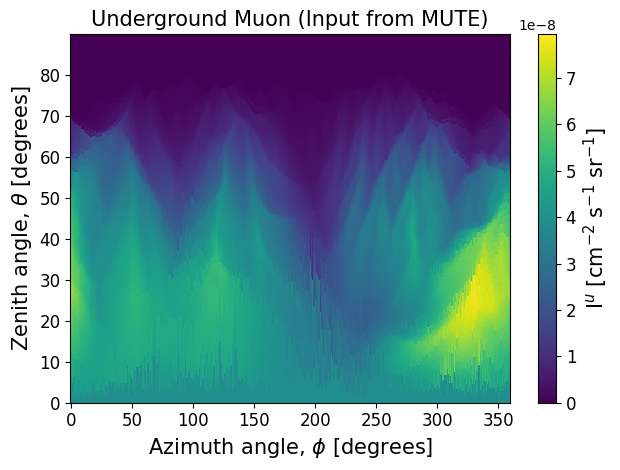

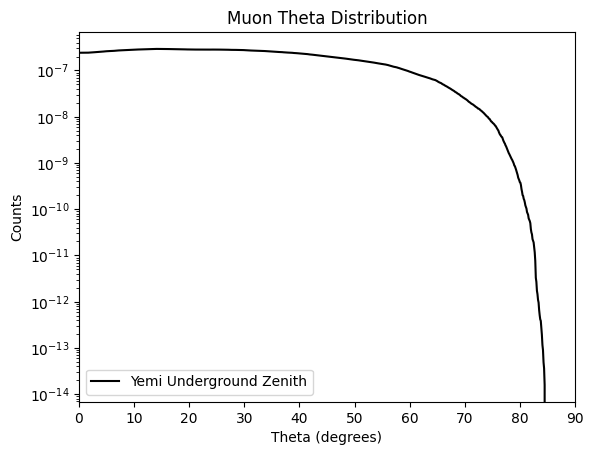

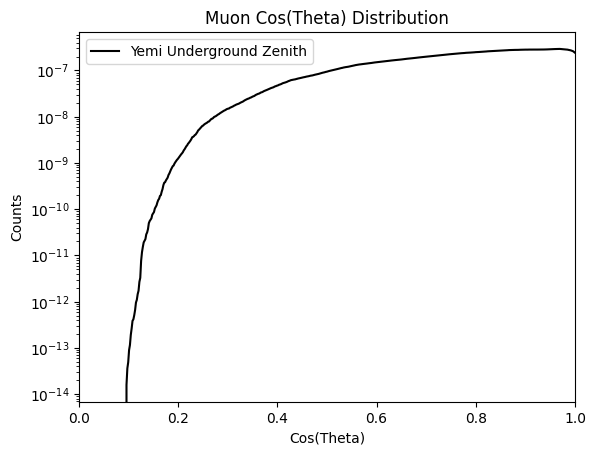

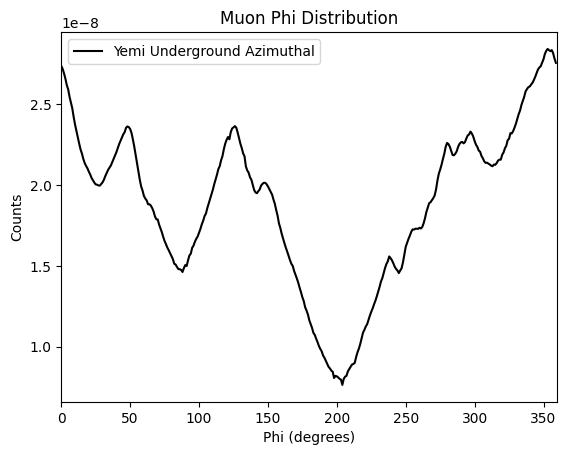

In [ ]:
fig, ax = plt.subplots()
X, Y = np.meshgrid(np.arange(0, 360, 1), np.arange(0, 90, 0.1))

cbar1 = plt.colorbar(ax.pcolormesh(X, Y, yemi_intensity['intensity'].values.reshape(900, 360), shading='auto', cmap='viridis'))
cbar1.set_label(r'I$^{u}$ [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)
cbar1.ax.tick_params(labelsize=12)
ax.set_xlabel(r'Azimuth angle, $\phi$ [degrees]', fontsize=15)
ax.set_ylabel(r'Zenith angle, $\theta$ [degrees]', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=12) 
ax.set_title('Underground Muon (Input from MUTE)', fontsize=15)
plt.tight_layout()
plt.show()


# Histogram
fig, ax = plt.subplots()
ax.plot(yemi_theta, yemi_theta_count, label='Yemi Underground Zenith', color='k')
ax.set_xlim(0, 90)
ax.set_xlabel('Theta (degrees)')
ax.set_ylabel('Counts')
ax.set_title('Muon Theta Distribution')
ax.set_yscale('log')
ax.legend()
plt.show()


fig, ax = plt.subplots()
ax.plot(np.cos(np.radians(yemi_theta)), yemi_theta_count, label='Yemi Underground Zenith', color='k')
ax.set_xlim(0, 1)
ax.set_xlabel('Cos(Theta)')
ax.set_ylabel('Counts')
ax.set_title('Muon Cos(Theta) Distribution')
ax.legend()
ax.set_yscale('log')
plt.show()

fig, ax = plt.subplots()
ax.plot(yemi_phi, yemi_phi_count, color='k', label='Yemi Underground Azimuthal')
ax.set_xlim(0, 360)
ax.set_xlabel('Phi (degrees)')
ax.set_ylabel('Counts')
ax.set_title('Muon Phi Distribution')
ax.legend()
plt.show()

In [46]:
costheta = np.cos(np.radians(yemi_theta))
idx = np.argsort(costheta)
costheta_sorted = costheta[idx]
theta_count_sorted = yemi_theta_count[idx]


theta_edges = np.unique(yemi_intensity['theta'])
phi_edges = np.unique(yemi_intensity['phi'])
Z = yemi_intensity['intensity'].values.reshape(900, 360)

with uproot.recreate('./yemi_underground_muon_angular_spectrum_from_MUTE.root') as f:
    f['hphi'] = (yemi_phi_count[:-1], yemi_phi)
    f['htheta'] = (yemi_theta_count[:-1], yemi_theta)
    f['hcostheta'] = (theta_count_sorted[:-1], costheta_sorted)
    f['h2D'] = (Z[:-1,:-1].T, phi_edges, theta_edges)
print('ROOT file created successfully with histograms.')

ROOT file created successfully with histograms.
